In [60]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import random as rnd
import math
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns

Data reading

In [61]:
# A - area, P - perimeter, C - compactness = 4*pi*A/P^2,
# LK - length of kernel, WK - width of kernel,
# Coef_A - asymmetry coefficient, LKG - length of kernel groove
df = pd.read_csv('../datasets/seeds_dataset.txt', sep='\t\t?', names=['A', 'P', 'C', 'LK', 'WK', 'Coef_A', 'LKG', 'Target'], engine='python')
df

,A,P,C,LK,WK,Coef_A,LKG,Target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


2D Data Visualization

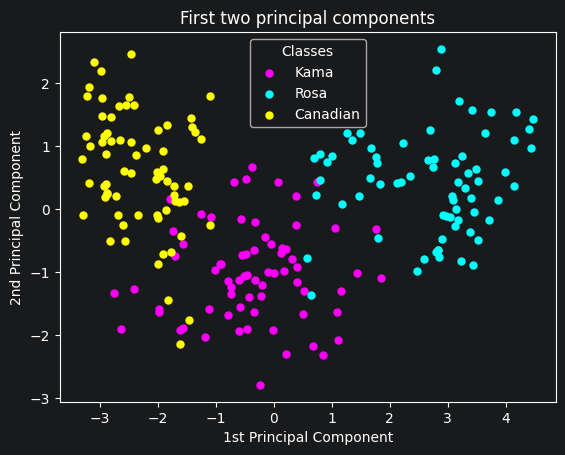

In [62]:
scaler = StandardScaler()
data = scaler.fit_transform(df.drop('Target', axis=1).values)
target = df['Target']
target_names = ['Kama', 'Rosa', 'Canadian']

pca = PCA(n_components=2)
X_reduced_PC_2 = pca.fit_transform(data)

colors = ['magenta', 'cyan', 'yellow']

for idx in range(0, len(target_names)):
    indexes = np.where(target == idx + 1)[0]
    plt.scatter(X_reduced_PC_2[indexes, 0], X_reduced_PC_2[indexes, 1], c=colors[idx], marker='.', s=100)
    plt.legend(target_names, loc="upper center", title="Classes")
plt.title("First two principal components")
plt.xlabel("1st Principal Component")
plt.ylabel("2nd Principal Component")
plt.show()

3D Data Visualization

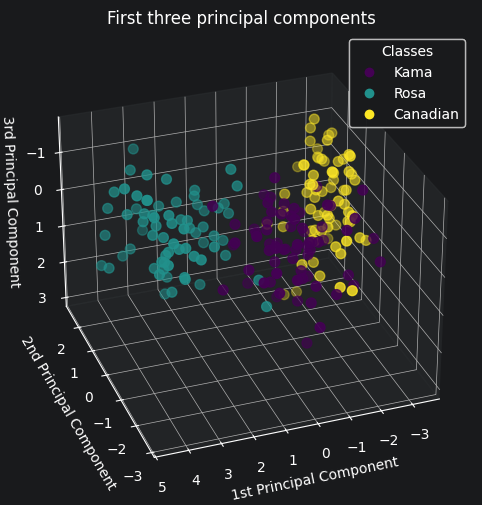

In [63]:
pca = PCA(n_components=3)
X_reduced_PC_3 = pca.fit_transform(data)

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)
scatter = ax.scatter(
    X_reduced_PC_3[:, 0],
    X_reduced_PC_3[:, 1],
    X_reduced_PC_3[:, 2],
    c=target,
    s=50,
)
ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)

legend = ax.legend(
    scatter.legend_elements()[0],
    target_names,
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend)
plt.show()

K-Means Clustering

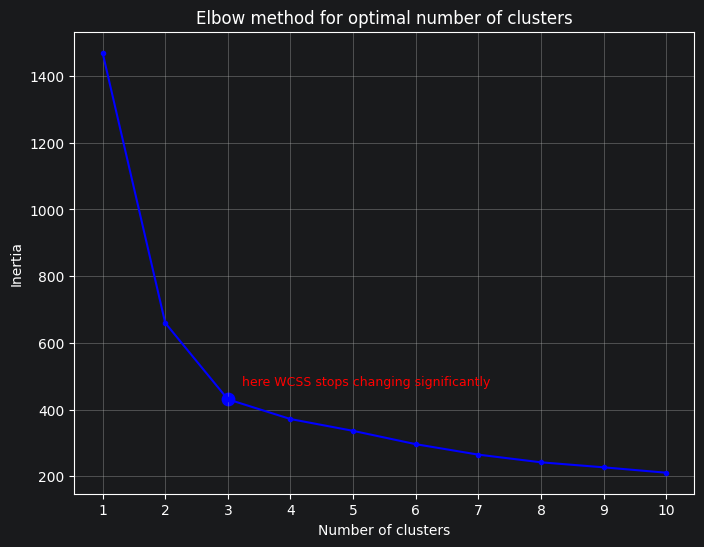

In [64]:
# Elbow method
inertia = []

for k in range (1, 11):
    k_means = KMeans(n_clusters=k, random_state=42)
    k_means.fit(data)
    inertia.append(k_means.inertia_)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, 11), inertia, marker='.', c='b')
ax.scatter(3, inertia[2], color="b", s=80)
ax.annotate(
    'here WCSS stops changing significantly',
    xy=(3, inertia[2]),
    xytext=(10, 10),
    textcoords="offset points",
    color='r',
    fontsize=9
)
ax.set_title("Elbow method for optimal number of clusters")
ax.set_xticks(range(1, 11))
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia")
plt.grid(True)
plt.show()


In [65]:
# silhouette score analysis
scores = []

for k in range(2, 11):
    k_means = KMeans(n_clusters=k, random_state=42)
    labels = k_means.fit_predict(data)
    silhouette = silhouette_score(data, labels)
    scores.append([k, silhouette])

best_silhouette = max(scores, key=lambda x: x[1])
print(f'The highest silhouette score: {best_silhouette[1]:.4f}, with number of clusters: {best_silhouette[0]}')

The highest silhouette score: 0.4615, with number of clusters: 2


Classical Kohonen Self-Organizing Map (SOM)

In [66]:
"""
    This implementation uses:
    - Euclidean distance for Best Matching Unit (BMU) search
    - Gaussian neighborhood function
    - Exponential decay of:
        * learning rate
        * neighborhood radius (sigma)

    Map size:
        10 x 10

    Typical workflow:
        1. Randomly initialize neuron weights
        2. For each sample:
            - find BMU
            - update BMU and neighboring neurons
        3. Gradually reduce:
            - learning rate
            - neighborhood radius
"""
class KohonenMap:
    def __init__(
        self,
        map_width=10,
        map_height=10,
        input_dimension=7,
        learning_rate=0.5,
        sigma=None
    ):
        self.map_width = map_width
        self.map_height = map_height
        self.input_dimension = input_dimension

        # Random initialization of neuron weights
        self.weights = np.random.rand(
            map_width,
            map_height,
            input_dimension
        )

        # Initial learning rate
        self.initial_learning_rate = learning_rate
        self.learning_rate = learning_rate

        # Initial neighborhood radius
        if sigma is None:
            sigma = max(map_width, map_height) / 2

        self.initial_sigma = sigma
        self.sigma = sigma


    def train(self, data, n_iterations=20000):
        # Time constant controls sigma decay speed
        # Formula: sigma(t) = sigma0 * exp(-t / time_constant)
        self.time_constant = n_iterations / math.log(self.initial_sigma)

        # STEP 1: Randomly choose one training sample
        # STEP 2: Find BMU
        # STEP 3: Update learning parameters
        # STEP 4: Update neuron weights
        for iteration in range(n_iterations):
            sample = data[rnd.randint(0, len(data) - 1)]
            bmu_index = self.find_bmu(sample)
            self.update_learning_rate(iteration, n_iterations)
            self.update_sigma(iteration)
            self.update_weights(sample, bmu_index)


    # Define win neuron
    def find_bmu(self, sample):
        min_distance = np.inf
        bmu_index = (0, 0)

        for i in range(self.map_width):
            for j in range(self.map_height):
                neuron_weight = self.weights[i, j]

                # Euclidean distance between input sample and neuron weight vector
                distance = np.linalg.norm(sample - neuron_weight)

                # Smaller distance means neuron better represents the sample
                if distance < min_distance:
                    min_distance = distance
                    bmu_index = (i, j)

        return bmu_index

    def neighborhood_function(self, neuron_position, bmu_position):
        # Distance between neuron positions on the 2D SOM grid
        grid_distance = np.linalg.norm(
            np.array(neuron_position) - np.array(bmu_position)
        )

        # Gaussian neighborhood function
        # formula: h(ci) = exp( -dist^2 / (2*sigma^2) )
        influence = np.exp(
            -(grid_distance ** 2) / (2 * (self.sigma ** 2))
        )

        return influence


    def update_weights(self, sample, bmu_index):
       for i in range(self.map_width):
          for j in range(self.map_height):
            neuron_position = (i, j)

            # Compute neighborhood influence
            influence = self.neighborhood_function(
                neuron_position,
                bmu_index
            )

            # SOM weight update:
            # w(t+1) = w(t) + learning_rate * neighborhood_influence * (sample - w(t))
            self.weights[i, j] += (
                self.learning_rate
                * influence
                * (sample - self.weights[i, j])
            )

    # Exponential learning rate decay.
    # Large learning at beginning: fast organization
    # Small learning at end: stable convergence
    # Formula: alpha(t) = alpha0 * exp(-t / T)
    def update_learning_rate(self, iteration, n_iterations):
        self.learning_rate = (
            self.initial_learning_rate
            * np.exp(-iteration / n_iterations)
        )

    # Exponential neighborhood radius decay
    # Large neighborhood early: global organization
    # Small neighborhood later: local fine tuning
    # Formula: sigma(t) = sigma0 * exp(-t / time_constant)
    def update_sigma(self, iteration):
        self.sigma = (
            self.initial_sigma
            * np.exp(-iteration / self.time_constant)
        )

    # Cluster assignment
    def map_vects(self, data):
        clusters = []

        for sample in data:
            bmu = self.find_bmu(sample)
            clusters.append(bmu)

        return clusters


# Create and Train SOM
som = KohonenMap(
    map_width=10,
    map_height=10,
    input_dimension=data.shape[1],
    learning_rate=0.5
)

som.train(data, n_iterations=20000)

U-Matrix (Unified-distance matrix) + Class Visualisation

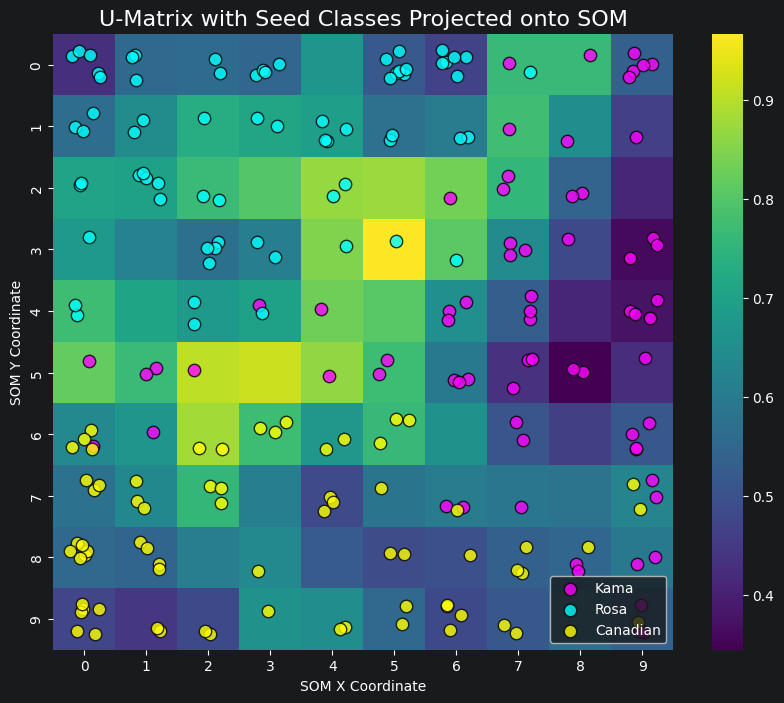

In [67]:
# 1. U-Matrix background
#    - shows distances between neighboring neurons
#    - bright regions -> cluster borders
#    - dark regions   -> similar neurons
#
# 2. Class projection
#    - samples are projected onto SOM
#    - colors represent known classes

u_matrix = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        current_weight = som.weights[i, j]
        neighbors = []

        if i > 0:
            neighbors.append(som.weights[i - 1, j]) # Top neighbor
        if i < 9:
            neighbors.append(som.weights[i + 1, j]) # Bottom neighbor
        if j > 0:
            neighbors.append(som.weights[i, j - 1]) # Left neighbor
        if j < 9:
            neighbors.append(som.weights[i, j + 1]) # Right neighbor

        distances = []

        for neighbor in neighbors:
            dist = np.linalg.norm(current_weight - neighbor)
            distances.append(dist)

        # Average neighbor distance
        u_matrix[i, j] = np.mean(distances)

plt.figure(figsize=(10, 8))

sns.heatmap(
    u_matrix,
    cmap='viridis',
    cbar=True
)

# Get BMU coordinates for all samples
bmus = som.map_vects(data)

colors = {
    1: 'magenta',
    2: 'cyan',
    3: 'yellow'
}

labels = {
    1: 'Kama',
    2: 'Rosa',
    3: 'Canadian'
}

for idx, (row, col) in enumerate(bmus):
    # Small random offsets prevent overlap
    x_offset = np.random.uniform(-0.25, 0.25)
    y_offset = np.random.uniform(-0.25, 0.25)

    plt.scatter(
        col + 0.5 + x_offset,
        row + 0.5 + y_offset,
        color=colors[target[idx]],
        edgecolors='black',
        s=80,
        alpha=0.8,
        label=labels[target[idx]]
    )


# Remove duplicate legend labels
handles, legend_labels = plt.gca().get_legend_handles_labels()

unique = dict(zip(legend_labels, handles))

plt.legend(
    unique.values(),
    unique.keys(),
    loc='lower right'
)
plt.title(
    'U-Matrix with Seed Classes Projected onto SOM',
    fontsize=16
)
plt.xlabel('SOM X Coordinate')
plt.ylabel('SOM Y Coordinate')

plt.show()